# <b> lec03_딥러닝_회귀

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#----------------------------------------------------------------------------------- ML 모델
from xgboost import XGBRegressor 
#----------------------------------------------------------------------------------  DL모델 
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
#-----------------------------------------------------------------------------------  평가
from sklearn.metrics import mean_squared_error

from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

sns.set()

#-------------------- 차트 관련 속성 (한글처리, 그리드) -----------
plt.rcParams['font.family']= 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

#-------------------- 주피터 , 출력결과 넓이 늘리기 ---------------
# from IPython.core.display import display, HTML
from IPython.display import display, HTML
display(HTML("<style>.container{width:100% !important;}</style>"))
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
pd.set_option('max_colwidth', None)

# <B>Data Load

In [2]:
df = pd.read_csv(r"C:\IT\workspace_ptyhon\basic\datas\Boston-house-price-data.csv")
df.columns = df.columns.str.lower()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    float64
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


# <b> 머신러닝(회귀) 모델 점수

In [3]:
y = df['medv']
X = df.drop('medv', axis=1)
print(X.shape,  y.shape)

X80,X20,y80,y20 = train_test_split(X, y, random_state=7825 )
print(X80.shape,X20.shape,y80.shape,y20.shape)

(506, 13) (506,)
(379, 13) (127, 13) (379,) (127,)


In [4]:
model = XGBRegressor(random_state=4567)
model.fit(X80, y80)
pred = model.predict(X20)

mse  = mean_squared_error(y20, pred)
rmse = np.sqrt(mse)
print(f"mse:{mse:.4f}\t rmse:{rmse:.4f}")
print()

mse:9.0452	 rmse:3.0075


# <b> 딥러닝 모델 점수

### <b> 1. 라이브러리 준비 및 환경 설정

In [5]:
#----------------------------------------------------------------------------------   DL 모델
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
#----------------------------------------------------------------------------------  평가
from sklearn.metrics  import accuracy_score,      f1_score

### <b> 2. 딥러닝 회귀 모델 구조 설계 (Model Build)

In [6]:
model = Sequential([
    Dense(units=10, activation="relu" , input_dim=13 ),   #----- input layer
    Dense(units=16, activation="relu"                ),   #----- hidden layer 3
    Dense(units=24, activation="relu"                ),    
    Dense(units=8,  activation="relu"                ),
    Dense(units=1                                    )    #----- output layer   
 ])

### <b> 3. 모델 컴파일 및 학습 규칙 설정 (Compile)

In [7]:
model.compile(loss="mse", optimizer="adam",  metrics=["mse"])   #-------------------- l o m

### <b> 4. 모델 요약 및 파람즈(Params) 확인

In [8]:
model.summary()

# param # : AI 모델이 학습을 통해 기억해야 할 '가중치(Weight)와 편향(Bias)의 총 개수 (공식의 개수)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 10)                  │             140 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 24)                  │             408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 8)                   │             200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 933 (3.64 KB)

 Trainable params: 933 (3.64 KB)

 Non-trainable params: 0 (0.00 B)

### <b> 5. 딥러닝 모델 학습 실행 (Fit)

In [9]:
res = model.fit(   X80, y80,   epochs=50,   validation_data =(X20,y20)   )
res

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 506.5887 - mse: 506.5887 - val_loss: 131.9084 - val_mse: 131.9084
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 132.5712 - mse: 132.5712 - val_loss: 91.2740 - val_mse: 91.2740
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 90.5391 - mse: 90.5391 - val_loss: 65.9400 - val_mse: 65.9400
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 75.9159 - mse: 75.9159 - val_loss: 58.0473 - val_mse: 58.0473
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 69.2964 - mse: 69.2964 - val_loss: 51.6380 - val_mse: 51.6380
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 68.8449 - mse: 68.8449 - val_loss: 53.4654 - val_mse: 53.4654
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 67.6773 - mse: 67.6773 - val_loss: 51.6234 - val_mse: 51.6234
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 67.3611 - mse: 67.3611 - val_loss: 52.8513 - val_mse: 52.8513
Epoch 9/50
12/12 ━━━━━━━━━━━━━━━━

### <b> 6. 최종 성능 평가 및 오차(RMSE) 분석

In [10]:
loss,mse = model.evaluate(X20,y20)
print("==================================================== ")
print(f" mse : {mse:.4f}, loss : {loss:.4f},      rmse : {np.sqrt(mse):.4f}")
print("==================================================== ")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 39.8379 - mse: 39.8379 
 mse : 39.8379, loss : 39.8379,      rmse : 6.3117


> <b><big>  cf. ML 모델 돌렸을때 결과 </b></big> (이전 회귀 ML 모델 결과임) <br>

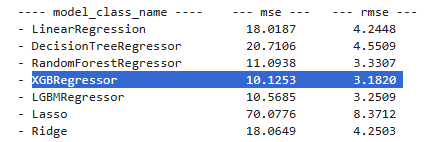

### <b> 학습 이력(History) 데이터 구조(keys) 확인

In [12]:
res.history.keys()

dict_keys(['loss', 'mse', 'val_loss', 'val_mse'])

### <b> 학습 결과 시각화 (Loss & MSE 그래프)

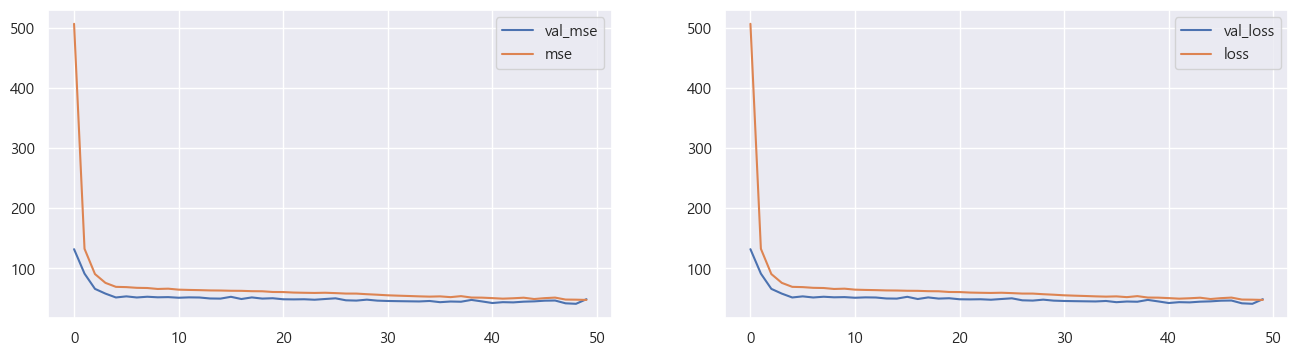

In [13]:
plt.figure(figsize=(16,4))
plt.subplot(1,2,1)
vacc = res.history["val_mse"]
acc  = res.history["mse"]
plt.plot(range(50), vacc , label="val_mse")
plt.plot(range(50), acc  , label="mse")
plt.legend()

plt.subplot(1,2,2)
vloss = res.history["val_loss"]
loss = res.history["loss"]
plt.plot(range(50),vloss , label="val_loss")
plt.plot(range(50),loss  , label="loss")
plt.legend()
plt.show();